# 🏥 WiDS Datathon 2020 — ICU Mortality Prediction
## Full Machine Learning & Deep Learning Pipeline

**Major:** Big Data Engineering  
**Domain:** Health (Santé)  
**Task:** Binary classification — predict `hospital_death` (0 = survived, 1 = died)  
**Metric:** AUC-ROC  
**Dataset:** 188 features · Training: ~91K rows · Test: 39,308 patients  

---
### Notebook Structure
- **Phase 1** — Setup & Data Loading
- **Phase 2** — Exploratory Data Analysis (EDA)
- **Phase 3** — Preprocessing & Feature Engineering
- **Phase 4** — Model Training & Evaluation (ML + DL)
- **Phase 5** — Explainability (SHAP + LIME)
- **Phase 6** — Submission Generation

---
## ⚙️ PHASE 1 — Environment Setup & Data Loading

In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
!pip install xgboost lightgbm shap lime imbalanced-learn optuna torch scikit-learn pandas numpy matplotlib seaborn missingno


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
print(sys.executable)
# Should show: C:\Users\rajaa\wids_project\venv\Scripts\python.exe

C:\Users\rajaa\wids_project\venv\Scripts\python.exe


In [5]:
# ── 1.1  Imports ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.experimental import enable_iterative_imputer   # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# Evaluation
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, RocCurveDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve

# Explainability
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('✅ All imports OK')

✅ All imports OK


In [7]:
# ── 1.2  Load Data ───────────────────────────────────────────────────────────
# ⚠️  Update paths to where your CSV files are located
DATA_DIR = './data/'   # <-- change this to your folder path

train      = pd.read_csv(DATA_DIR + 'training_v2.csv')
test       = pd.read_csv(DATA_DIR + 'unlabeled.csv')
dictionary = pd.read_csv(DATA_DIR + 'WiDS Datathon 2020 Dictionary.csv')
solution   = pd.read_csv(DATA_DIR + 'solution_template.csv')
sample_sub = pd.read_csv(DATA_DIR + 'samplesubmission.csv')

print(f'Train shape : {train.shape}')     # expected ~91K rows × 186 cols
print(f'Test shape  : {test.shape}')      # expected ~39K rows × 185 cols (no target)
print(f'Solution    : {solution.shape}')  # 39308 × 2
print(f'Dictionary  : {dictionary.shape}')
print()
print('Train columns:', train.columns.tolist()[:10], '...')
print('Target distribution:')
print(train['hospital_death'].value_counts())
print(f'Positive rate: {train["hospital_death"].mean():.2%}')

Train shape : (91713, 186)
Test shape  : (39308, 186)
Solution    : (39308, 2)
Dictionary  : (188, 6)

Train columns: ['encounter_id', 'patient_id', 'hospital_id', 'hospital_death', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height'] ...
Target distribution:
hospital_death
0    83798
1     7915
Name: count, dtype: int64
Positive rate: 8.63%


In [9]:
# ── 1.3  Feature Registry from Dictionary ────────────────────────────────────
# Exact feature lists by category (from WiDS_Datathon_2020_Dictionary.csv)

ID_COLS = ['encounter_id', 'hospital_id', 'patient_id']

TARGET = 'hospital_death'

BINARY_FEATURES = [
    'elective_surgery', 'readmission_status', 'apache_post_operative',
    'arf_apache', 'gcs_unable_apache', 'intubated_apache', 'ventilated_apache',
    'aids', 'cirrhosis', 'diabetes_mellitus', 'hepatic_failure',
    'immunosuppression', 'leukemia', 'lymphoma', 'solid_tumor_with_metastasis'
]

CATEGORICAL_FEATURES = [
    'bmi', 'ethnicity', 'gender',
    'hospital_admit_source', 'icu_admit_source', 'icu_admit_type',
    'icu_stay_type', 'icu_type',
    'apache_2_diagnosis', 'apache_3j_diagnosis',
    'apache_3j_bodysystem', 'apache_2_bodysystem'
]

VITALS = [
    'd1_diasbp_invasive_max','d1_diasbp_invasive_min','d1_diasbp_max','d1_diasbp_min',
    'd1_diasbp_noninvasive_max','d1_diasbp_noninvasive_min',
    'd1_heartrate_max','d1_heartrate_min','d1_mbp_invasive_max','d1_mbp_invasive_min',
    'd1_mbp_max','d1_mbp_min','d1_mbp_noninvasive_max','d1_mbp_noninvasive_min',
    'd1_resprate_max','d1_resprate_min','d1_spo2_max','d1_spo2_min',
    'd1_sysbp_invasive_max','d1_sysbp_invasive_min','d1_sysbp_max','d1_sysbp_min',
    'd1_sysbp_noninvasive_max','d1_sysbp_noninvasive_min','d1_temp_max','d1_temp_min',
    'h1_diasbp_invasive_max','h1_diasbp_invasive_min','h1_diasbp_max','h1_diasbp_min',
    'h1_diasbp_noninvasive_max','h1_diasbp_noninvasive_min',
    'h1_heartrate_max','h1_heartrate_min','h1_mbp_invasive_max','h1_mbp_invasive_min',
    'h1_mbp_max','h1_mbp_min','h1_mbp_noninvasive_max','h1_mbp_noninvasive_min',
    'h1_resprate_max','h1_resprate_min','h1_spo2_max','h1_spo2_min',
    'h1_sysbp_invasive_max','h1_sysbp_invasive_min','h1_sysbp_max','h1_sysbp_min',
    'h1_sysbp_noninvasive_max','h1_sysbp_noninvasive_min','h1_temp_max','h1_temp_min'
]

LABS = [
    'd1_albumin_max','d1_albumin_min','d1_bilirubin_max','d1_bilirubin_min',
    'd1_bun_max','d1_bun_min','d1_calcium_max','d1_calcium_min',
    'd1_creatinine_max','d1_creatinine_min','d1_glucose_max','d1_glucose_min',
    'd1_hco3_max','d1_hco3_min','d1_hemaglobin_max','d1_hemaglobin_min',
    'd1_hematocrit_max','d1_hematocrit_min','d1_inr_max','d1_inr_min',
    'd1_lactate_max','d1_lactate_min','d1_platelets_max','d1_platelets_min',
    'd1_potassium_max','d1_potassium_min','d1_sodium_max','d1_sodium_min',
    'd1_wbc_max','d1_wbc_min',
    'h1_albumin_max','h1_albumin_min','h1_bilirubin_max','h1_bilirubin_min',
    'h1_bun_max','h1_bun_min','h1_calcium_max','h1_calcium_min',
    'h1_creatinine_max','h1_creatinine_min','h1_glucose_max','h1_glucose_min',
    'h1_hco3_max','h1_hco3_min','h1_hemaglobin_max','h1_hemaglobin_min',
    'h1_hematocrit_max','h1_hematocrit_min','h1_inr_max','h1_inr_min',
    'h1_lactate_max','h1_lactate_min','h1_platelets_max','h1_platelets_min',
    'h1_potassium_max','h1_potassium_min','h1_sodium_max','h1_sodium_min',
    'h1_wbc_max','h1_wbc_min'
]

LABS_BG = [
    'd1_arterial_pco2_max','d1_arterial_pco2_min','d1_arterial_ph_max','d1_arterial_ph_min',
    'd1_arterial_po2_max','d1_arterial_po2_min','d1_pao2fio2ratio_max','d1_pao2fio2ratio_min',
    'h1_arterial_pco2_max','h1_arterial_pco2_min','h1_arterial_ph_max','h1_arterial_ph_min',
    'h1_arterial_po2_max','h1_arterial_po2_min','h1_pao2fio2ratio_max','h1_pao2fio2ratio_min'
]

APACHE_COV = [
    'albumin_apache','bilirubin_apache','bun_apache','creatinine_apache',
    'fio2_apache','gcs_eyes_apache','gcs_motor_apache','gcs_verbal_apache',
    'glucose_apache','heart_rate_apache','hematocrit_apache','map_apache',
    'paco2_apache','paco2_for_ph_apache','pao2_apache','ph_apache',
    'resprate_apache','sodium_apache','temp_apache','urineoutput_apache','wbc_apache'
]

COMORBIDITIES = [
    'aids','cirrhosis','diabetes_mellitus','hepatic_failure',
    'immunosuppression','leukemia','lymphoma','solid_tumor_with_metastasis'
]

APACHE_PRED = ['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']  # baseline to beat

NUMERIC_FEATURES = (
    ['age','height','weight','pre_icu_los_days'] +
    APACHE_COV + VITALS + LABS + LABS_BG
)

GCS_COLS = ['gcs_eyes_apache','gcs_motor_apache','gcs_verbal_apache']

print('✅ Feature registry created')
print(f'  Numeric  : {len(NUMERIC_FEATURES)}')
print(f'  Binary   : {len(BINARY_FEATURES)}')
print(f'  Categ.   : {len(CATEGORICAL_FEATURES)}')
print(f'  Baseline : {APACHE_PRED}')

✅ Feature registry created
  Numeric  : 153
  Binary   : 15
  Categ.   : 12
  Baseline : ['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']


---
## 📊 PHASE 2 — Exploratory Data Analysis

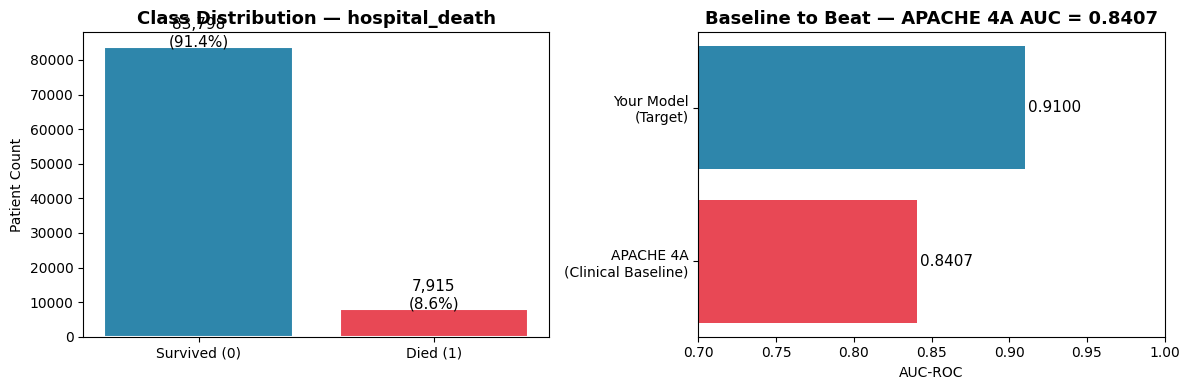

✅ APACHE 4A Baseline AUC: 0.8407  ← your models must beat this!


In [11]:
# ── 2.1  Class Imbalance ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train[TARGET].value_counts()
axes[0].bar(['Survived (0)', 'Died (1)'], counts.values, color=['#2E86AB','#E84855'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution — hospital_death', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Patient Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(train):.1%})', ha='center', fontsize=11)

# Apache 4A baseline AUC
mask = train['apache_4a_hospital_death_prob'].notna()
baseline_auc = roc_auc_score(train.loc[mask, TARGET], train.loc[mask, 'apache_4a_hospital_death_prob'])
axes[1].barh(['APACHE 4A\n(Clinical Baseline)', 'Your Model\n(Target)'],
             [baseline_auc, 0.91], color=['#E84855','#2E86AB'])
axes[1].set_xlim(0.7, 1.0)
axes[1].set_title(f'Baseline to Beat — APACHE 4A AUC = {baseline_auc:.4f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('AUC-ROC')
for i, v in enumerate([baseline_auc, 0.91]):
    axes[1].text(v+0.002, i, f'{v:.4f}', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ APACHE 4A Baseline AUC: {baseline_auc:.4f}  ← your models must beat this!')

Features with ANY missing: 175 / 186
Features with >50% missing: 74
Features with >30% missing: 74

Top 20 most missing:
             feature  missing_pct
    h1_bilirubin_min    92.265001
    h1_bilirubin_max    92.265001
      h1_lactate_min    91.992411
      h1_lactate_max    91.992411
      h1_albumin_max    91.398166
      h1_albumin_min    91.398166
h1_pao2fio2ratio_min    87.441257
h1_pao2fio2ratio_max    87.441257
  h1_arterial_ph_max    83.329517
  h1_arterial_ph_min    83.329517
         h1_hco3_max    82.969699
         h1_hco3_min    82.969699
h1_arterial_pco2_max    82.822501
h1_arterial_pco2_min    82.822501
          h1_wbc_max    82.815958
          h1_wbc_min    82.815958
 h1_arterial_po2_min    82.807236
 h1_arterial_po2_max    82.807236
      h1_calcium_max    82.717826
      h1_calcium_min    82.717826


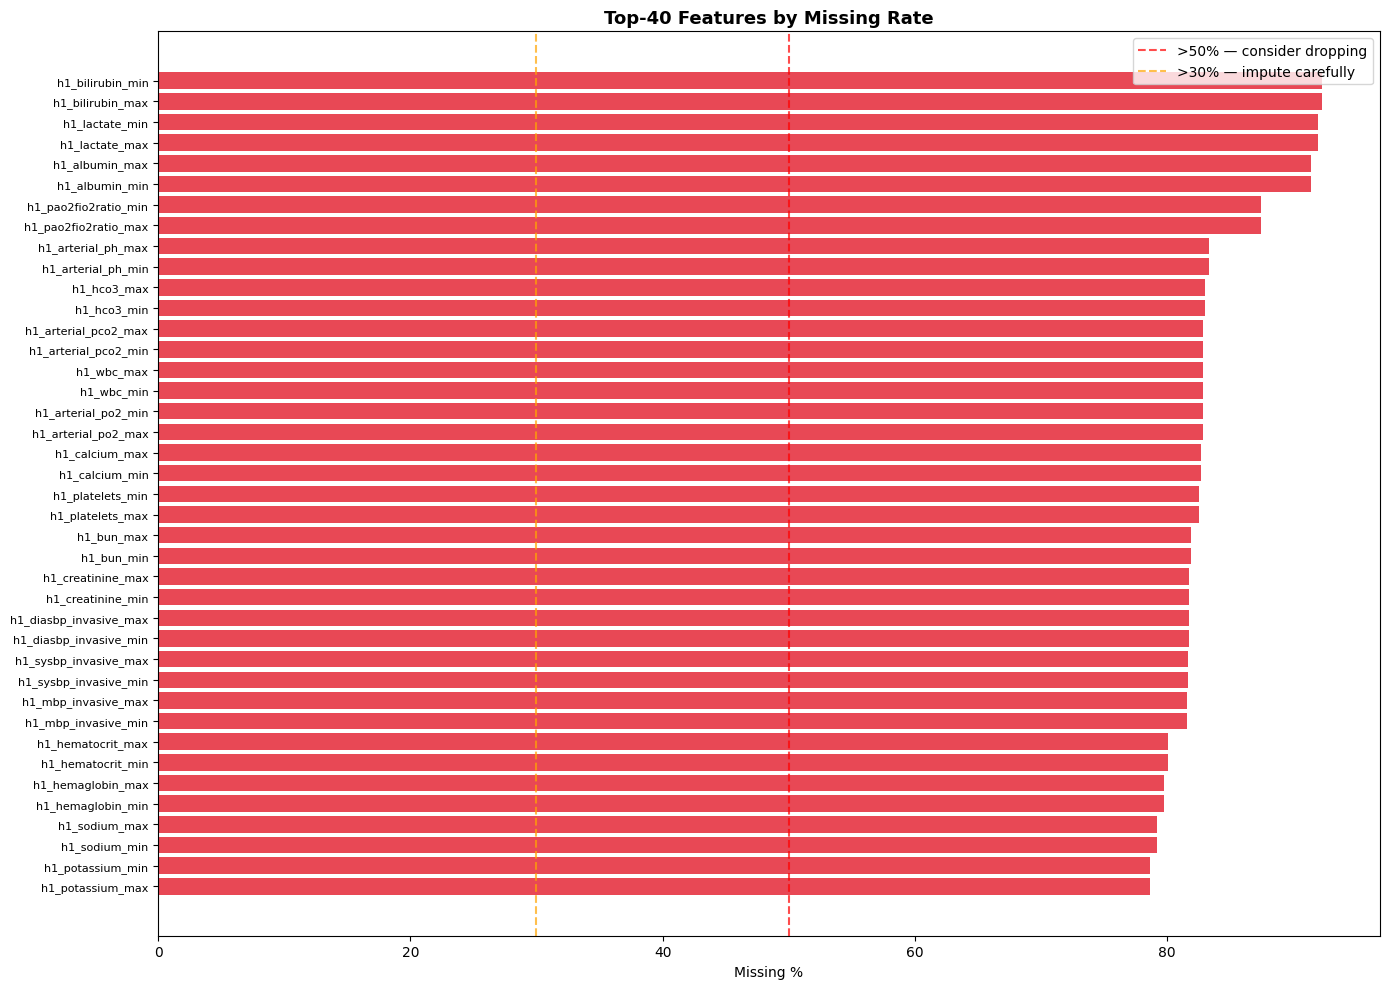

In [13]:
# ── 2.2  Missing Data Analysis ───────────────────────────────────────────────
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['feature', 'missing_pct']

print(f'Features with ANY missing: {len(missing_df)} / {train.shape[1]}')
print(f'Features with >50% missing: {(missing_df.missing_pct > 50).sum()}')
print(f'Features with >30% missing: {(missing_df.missing_pct > 30).sum()}')
print()
print('Top 20 most missing:')
print(missing_df.head(20).to_string(index=False))

# Plot top-40 missing
fig, ax = plt.subplots(figsize=(14, 10))
top40 = missing_df.head(40)
colors = ['#E84855' if p>50 else '#F4A261' if p>30 else '#2E86AB' for p in top40.missing_pct]
ax.barh(range(len(top40)), top40.missing_pct, color=colors)
ax.set_yticks(range(len(top40)))
ax.set_yticklabels(top40.feature, fontsize=8)
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='>50% — consider dropping')
ax.axvline(30, color='orange', linestyle='--', alpha=0.7, label='>30% — impute carefully')
ax.set_xlabel('Missing %')
ax.set_title('Top-40 Features by Missing Rate', fontsize=13, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('eda_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

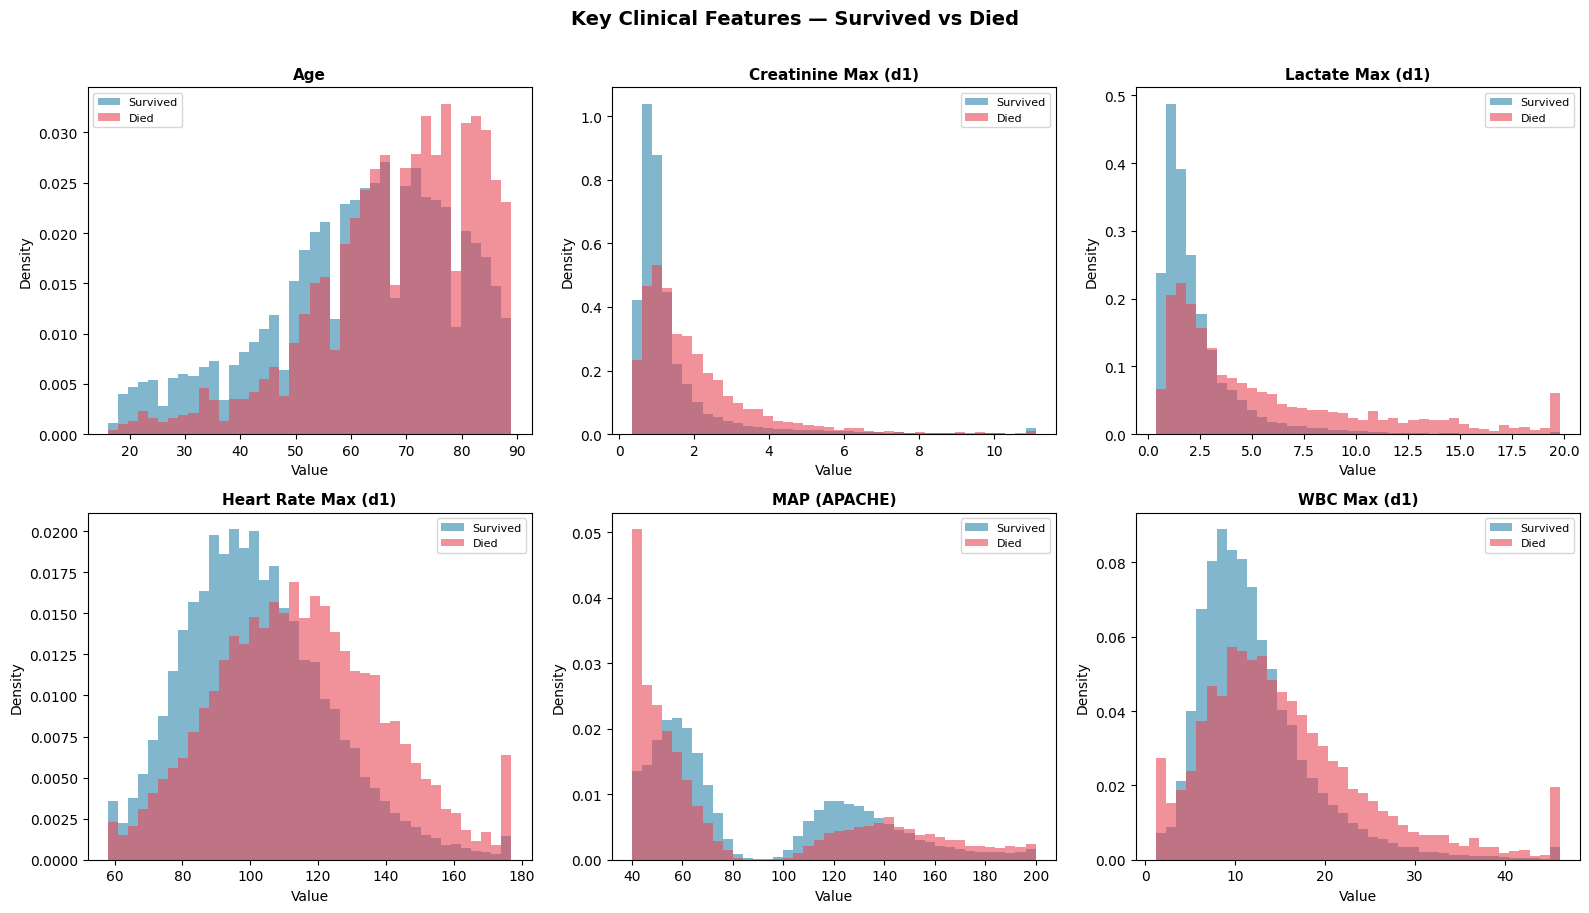

In [15]:
# ── 2.3  Key Clinical Feature Distributions by Survival ─────────────────────
key_features = [
    ('age', 'Age'),
    ('d1_creatinine_max', 'Creatinine Max (d1)'),
    ('d1_lactate_max', 'Lactate Max (d1)'),
    ('d1_heartrate_max', 'Heart Rate Max (d1)'),
    ('map_apache', 'MAP (APACHE)'),
    ('d1_wbc_max', 'WBC Max (d1)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (feat, label) in zip(axes.flat, key_features):
    if feat not in train.columns:
        ax.set_visible(False)
        continue
    survived = train.loc[train[TARGET]==0, feat].dropna()
    died     = train.loc[train[TARGET]==1, feat].dropna()
    ax.hist(survived, bins=40, alpha=0.6, color='#2E86AB', label='Survived', density=True)
    ax.hist(died,     bins=40, alpha=0.6, color='#E84855', label='Died',     density=True)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Key Clinical Features — Survived vs Died', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

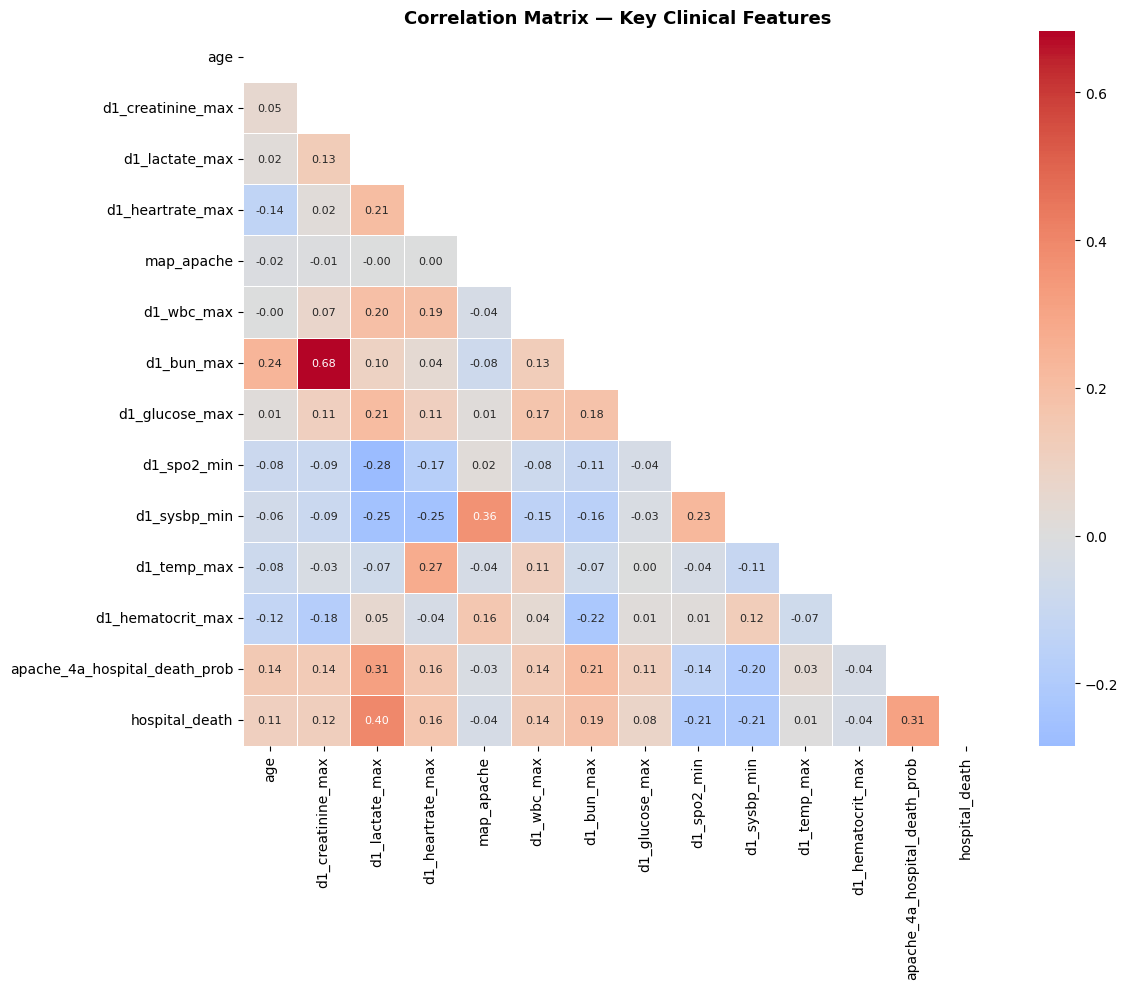

In [17]:
# ── 2.4  Correlation Heatmap (top numeric features) ──────────────────────────
top_numeric = [
    'age','d1_creatinine_max','d1_lactate_max','d1_heartrate_max',
    'map_apache','d1_wbc_max','d1_bun_max','d1_glucose_max',
    'd1_spo2_min','d1_sysbp_min','d1_temp_max','d1_hematocrit_max',
    'apache_4a_hospital_death_prob', TARGET
]
top_numeric = [f for f in top_numeric if f in train.columns]

corr = train[top_numeric].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size':8})
ax.set_title('Correlation Matrix — Key Clinical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

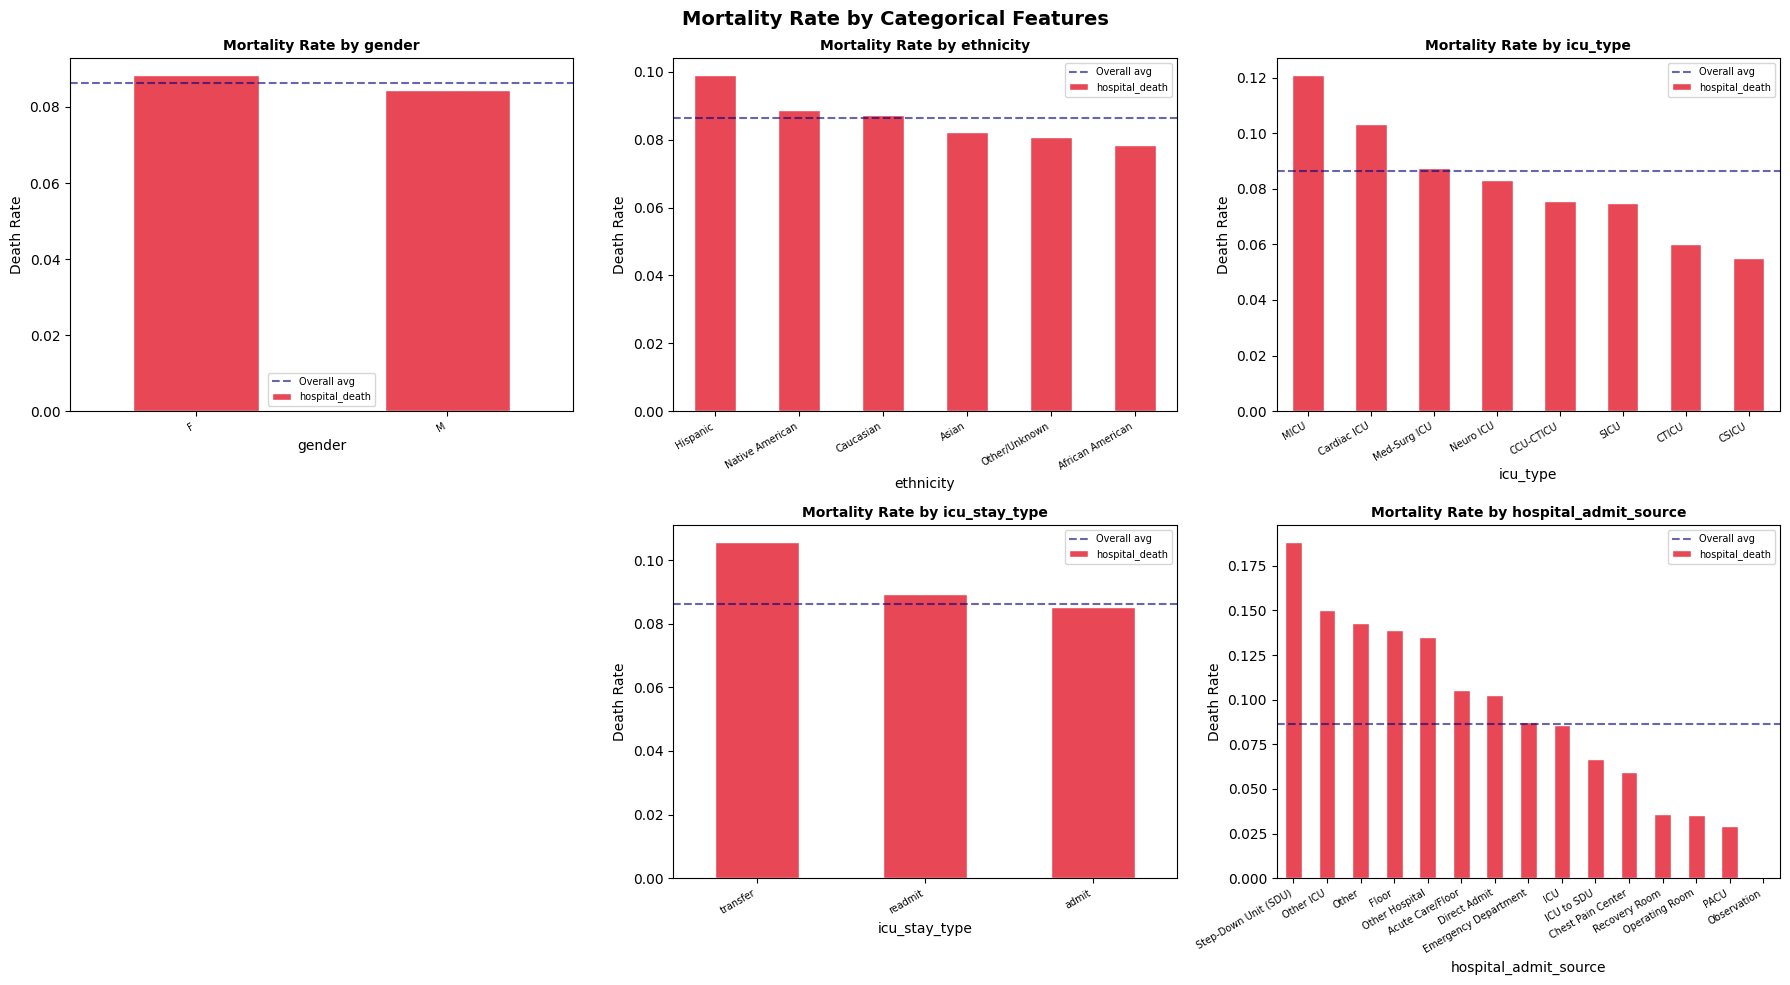

In [19]:
# ── 2.5  Categorical Feature Analysis ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cat_to_plot = ['gender','ethnicity','icu_type','icu_admit_type','icu_stay_type','hospital_admit_source']

for ax, col in zip(axes.flat, cat_to_plot):
    if col not in train.columns:
        ax.set_visible(False)
        continue
    mort_rate = train.groupby(col)[TARGET].mean().sort_values(ascending=False)
    mort_rate.plot(kind='bar', ax=ax, color='#E84855', edgecolor='white', linewidth=1)
    ax.set_title(f'Mortality Rate by {col}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Death Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)
    ax.axhline(train[TARGET].mean(), color='navy', linestyle='--', alpha=0.6, label='Overall avg')
    ax.legend(fontsize=7)

plt.suptitle('Mortality Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 PHASE 3 — Preprocessing & Feature Engineering

In [21]:
# ── 3.1  Combine train + test for consistent preprocessing ───────────────────
train_copy = train.copy()
test_copy  = test.copy()

# Mark source
train_copy['_is_train'] = 1
test_copy['_is_train']  = 0
test_copy[TARGET]       = np.nan  # placeholder

# Save encounter IDs for submission
test_encounter_ids = test_copy['encounter_id'].values

# Combine
combined = pd.concat([train_copy, test_copy], ignore_index=True)
print(f'Combined shape: {combined.shape}')

Combined shape: (131021, 187)


In [23]:
# ── 3.2  Drop columns with >60% missing + identifiers ────────────────────────
missing_pct = combined.isnull().mean()
high_missing = missing_pct[missing_pct > 0.60].index.tolist()

# Never drop these even if high missing
KEEP_ALWAYS = APACHE_PRED + [TARGET, '_is_train']
drop_high   = [c for c in high_missing if c not in KEEP_ALWAYS and c not in ID_COLS]

# Drop IDs and high-missing
cols_to_drop = ID_COLS + ['icu_id'] + drop_high   # icu_id is an ID, not a feature
combined.drop(columns=[c for c in cols_to_drop if c in combined.columns], inplace=True)

print(f'Dropped {len(drop_high)} high-missing features (>60%): {drop_high[:10]}...')
print(f'Remaining columns: {combined.shape[1]}')

Dropped 67 high-missing features (>60%): ['albumin_apache', 'bilirubin_apache', 'fio2_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_mbp_invasive_max']...
Remaining columns: 116


In [25]:
# ── 3.3  Feature Engineering ─────────────────────────────────────────────────
def engineer_features(df):
    df = df.copy()

    # Shock index = heart rate / systolic BP (high → shock risk)
    if 'd1_heartrate_max' in df.columns and 'd1_sysbp_min' in df.columns:
        df['shock_index_d1'] = df['d1_heartrate_max'] / (df['d1_sysbp_min'].replace(0, np.nan) + 1e-6)

    # Pulse pressure = SBP - DBP (narrowing → poor perfusion)
    if 'd1_sysbp_max' in df.columns and 'd1_diasbp_min' in df.columns:
        df['pulse_pressure_d1'] = df['d1_sysbp_max'] - df['d1_diasbp_min']

    # Vital ranges (max - min) — variability as instability signal
    for base in ['heartrate', 'sysbp', 'diasbp', 'resprate', 'temp', 'spo2']:
        mx = f'd1_{base}_max'
        mn = f'd1_{base}_min'
        if mx in df.columns and mn in df.columns:
            df[f'{base}_range_d1'] = df[mx] - df[mn]

    # GCS total score (neurological status)
    gcs_cols_present = [c for c in GCS_COLS if c in df.columns]
    if len(gcs_cols_present) == 3:
        df['gcs_total'] = df[gcs_cols_present].sum(axis=1)

    # Creatinine / BUN ratio (kidney function marker)
    if 'd1_creatinine_max' in df.columns and 'd1_bun_max' in df.columns:
        df['bun_creatinine_ratio'] = df['d1_bun_max'] / (df['d1_creatinine_max'].replace(0, np.nan) + 1e-6)

    # Age bins (risk stratification)
    if 'age' in df.columns:
        df['age_group'] = pd.cut(df['age'], bins=[0,45,65,75,120],
                                  labels=['young','middle','senior','elderly'])

    return df

combined = engineer_features(combined)
print(f'After feature engineering: {combined.shape[1]} columns')
new_feats = [c for c in combined.columns if c in [
    'shock_index_d1','pulse_pressure_d1','gcs_total','bun_creatinine_ratio',
    'heartrate_range_d1','sysbp_range_d1','resprate_range_d1'
]]
print(f'New engineered features: {new_feats}')

After feature engineering: 127 columns
New engineered features: ['shock_index_d1', 'pulse_pressure_d1', 'heartrate_range_d1', 'sysbp_range_d1', 'resprate_range_d1', 'gcs_total', 'bun_creatinine_ratio']


In [27]:
# ── 3.4  Encode Categorical Features ─────────────────────────────────────────
# bmi is stored as string but is actually numeric — fix it
if 'bmi' in combined.columns:
    combined['bmi'] = pd.to_numeric(combined['bmi'], errors='coerce')

# One-hot encode low-cardinality categoricals
LOW_CARD_CATS = [
    'gender','ethnicity','icu_type','icu_admit_type',
    'icu_stay_type','hospital_admit_source','icu_admit_source',
    'apache_3j_bodysystem','apache_2_bodysystem'
]

# High-cardinality — label encode (too many categories for OHE)
HIGH_CARD_CATS = ['apache_2_diagnosis','apache_3j_diagnosis']

# age_group (engineered)
if 'age_group' in combined.columns:
    combined['age_group'] = combined['age_group'].astype(str)
    LOW_CARD_CATS.append('age_group')

# Label encode high-cardinality
le = LabelEncoder()
for col in HIGH_CARD_CATS:
    if col in combined.columns:
        combined[col] = combined[col].fillna('Unknown')
        combined[col] = le.fit_transform(combined[col].astype(str))

# One-hot encode low-cardinality
low_card_present = [c for c in LOW_CARD_CATS if c in combined.columns]
combined = pd.get_dummies(combined, columns=low_card_present, drop_first=False, dtype=int)

print(f'After encoding: {combined.shape[1]} columns')

After encoding: 182 columns


In [29]:
# ── 3.5  Missing Value Imputation ────────────────────────────────────────────
# Split back BEFORE imputation (impute train only, apply to test)
is_train_mask = combined['_is_train'] == 1

# Separate metadata
meta_cols   = [TARGET, '_is_train']
feature_cols = [c for c in combined.columns if c not in meta_cols]

X_all = combined[feature_cols].copy()

# Binary cols: fill NaN with 0 (not present = no comorbidity)
binary_present = [c for c in BINARY_FEATURES if c in X_all.columns]
X_all[binary_present] = X_all[binary_present].fillna(0)

# Numeric: median imputation (fast & safe for large datasets)
# For a smaller subset you could use IterativeImputer (MICE) — see commented code below
num_cols = X_all.select_dtypes(include=[np.number]).columns.tolist()
num_imputer = SimpleImputer(strategy='median')

X_train_imp = X_all[is_train_mask].copy()
X_test_imp  = X_all[~is_train_mask].copy()

X_train_imp[num_cols] = num_imputer.fit_transform(X_train_imp[num_cols])
X_test_imp[num_cols]  = num_imputer.transform(X_test_imp[num_cols])

# ── Optional: MICE imputation (slower but more accurate) ─────────────────────
# mice = IterativeImputer(max_iter=10, random_state=SEED)
# X_train_imp[num_cols] = mice.fit_transform(X_train_imp[num_cols])
# X_test_imp[num_cols]  = mice.transform(X_test_imp[num_cols])

y_train = combined.loc[is_train_mask, TARGET].values.astype(int)

print(f'X_train shape: {X_train_imp.shape}')
print(f'X_test  shape: {X_test_imp.shape}')
print(f'y_train — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}  positive rate: {y_train.mean():.2%}')

X_train shape: (91713, 180)
X_test  shape: (39308, 180)
y_train — 0: 83798  1: 7915  positive rate: 8.63%


In [31]:
# ── 3.6  SMOTE — Handle Class Imbalance ──────────────────────────────────────
# Apply SMOTE on training only — NEVER on test
X_np = X_train_imp.values

smote = SMOTE(sampling_strategy=0.3, random_state=SEED)  # bring minority to 30% of majority
X_resampled, y_resampled = smote.fit_resample(X_np, y_train)

X_resampled_df = pd.DataFrame(X_resampled, columns=X_train_imp.columns)

print(f'Before SMOTE — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}')
print(f'After  SMOTE — 0: {(y_resampled==0).sum()}  1: {(y_resampled==1).sum()}')

# Use both versions — some models work better without SMOTE (use class_weight instead)
X_train_final = X_resampled_df
y_train_final = y_resampled

# Original (no SMOTE) for XGBoost with scale_pos_weight
X_orig = X_train_imp.copy()
y_orig = y_train.copy()
scale_pos_weight = (y_orig==0).sum() / (y_orig==1).sum()
print(f'scale_pos_weight for XGBoost: {scale_pos_weight:.2f}')

Before SMOTE — 0: 83798  1: 7915
After  SMOTE — 0: 83798  1: 25139
scale_pos_weight for XGBoost: 10.59


In [33]:
# ── 3.7  Train / Val Split ───────────────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_orig, y_orig, test_size=0.20, stratify=y_orig, random_state=SEED
)
print(f'Train: {X_tr.shape}  Val: {X_val.shape}')
print(f'Val positive rate: {y_val.mean():.2%}')

# Also prepare scaled version (needed for MLP)
scaler = StandardScaler()
X_tr_scaled  = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_imp.values)

Train: (73370, 180)  Val: (18343, 180)
Val positive rate: 8.63%


---
## 🤖 PHASE 4 — Model Training & Evaluation

### 4A — Classical ML Models

In [35]:
# ── Helper: evaluate any model ───────────────────────────────────────────────
def evaluate_model(name, model, X_val, y_val, proba=True):
    if proba:
        y_prob = model.predict_proba(X_val)[:, 1]
    else:
        y_prob = model.predict(X_val)
    y_pred = (y_prob >= 0.5).astype(int)

    auc  = roc_auc_score(y_val, y_prob)
    f1   = f1_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred)
    acc  = accuracy_score(y_val, y_pred)
    brier = brier_score_loss(y_val, y_prob)

    print(f'\n── {name} ──')
    print(f'  AUC-ROC  : {auc:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Brier    : {brier:.4f}')

    return {'name': name, 'auc': auc, 'f1': f1, 'precision': prec,
            'recall': rec, 'accuracy': acc, 'brier': brier, 'proba': y_prob}

results = {}  # store all model results
print('✅ Evaluation helper ready')

✅ Evaluation helper ready


In [37]:
# ── 4A.1  Logistic Regression (Baseline) ─────────────────────────────────────
lr = LogisticRegression(
    C=1.0, penalty='l2', solver='saga',
    class_weight='balanced', max_iter=500, random_state=SEED, n_jobs=-1
)
lr.fit(X_tr_scaled, y_tr)
results['LogisticRegression'] = evaluate_model('Logistic Regression', lr, X_val_scaled, y_val)


── Logistic Regression ──
  AUC-ROC  : 0.8876
  F1-Score : 0.4213
  Precision: 0.2878
  Recall   : 0.7858
  Accuracy : 0.8137
  Brier    : 0.1342


In [39]:
# ── 4A.2  Random Forest ───────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)
results['RandomForest'] = evaluate_model('Random Forest', rf, X_val, y_val)


── Random Forest ──
  AUC-ROC  : 0.8879
  F1-Score : 0.4884
  Precision: 0.4163
  Recall   : 0.5907
  Accuracy : 0.8932
  Brier    : 0.0855


In [41]:
# ── 4A.3  LightGBM ───────────────────────────────────────────────────────────
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=50,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    is_unbalance=True,   # handles imbalance internally
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)]
)
results['LightGBM'] = evaluate_model('LightGBM', lgb_model, X_val, y_val)


── LightGBM ──
  AUC-ROC  : 0.8728
  F1-Score : 0.0000
  Precision: 0.0000
  Recall   : 0.0000
  Accuracy : 0.9137
  Brier    : 0.0701


In [43]:
# ── 4A.4  XGBoost (Primary Strong Model) ─────────────────────────────────────
# ── 4A.4  XGBoost (Primary Strong Model) ─────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=50,        # ← moved here in XGBoost 3.x
    random_state=SEED,
    n_jobs=-1
)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=200
)
results['XGBoost'] = evaluate_model('XGBoost', xgb_model, X_val, y_val)

[0]	validation_0-auc:0.85282
[200]	validation_0-auc:0.90013
[336]	validation_0-auc:0.90147

── XGBoost ──
  AUC-ROC  : 0.9018
  F1-Score : 0.4816
  Precision: 0.3571
  Recall   : 0.7391
  Accuracy : 0.8627
  Brier    : 0.0972


### 4B — Deep Learning Models (PyTorch)

In [45]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cpu')
print(f'Using device: {device}')

def make_tensors(X, y=None):
    X_t = torch.tensor(X, dtype=torch.float32)
    if y is not None:
        return X_t, torch.tensor(y, dtype=torch.float32)
    return X_t

X_tr_t, y_tr_t   = make_tensors(X_tr_scaled, y_tr)
X_val_t, y_val_t = make_tensors(X_val_scaled, y_val)
X_test_t          = make_tensors(X_test_scaled)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=512, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=1024, shuffle=False)

n_features = X_tr_scaled.shape[1]
print(f'Input features: {n_features}')
print('✅ PyTorch CPU ready')

OSError: [WinError 127] La procédure spécifiée est introuvable. Error loading "C:\Users\rajaa\wids_project\venv\Lib\site-packages\torch\lib\c10_cuda.dll" or one of its dependencies.

In [ ]:
# ── 4B.1  MLP — 4-Layer Tabular Neural Network ───────────────────────────────
class MLP(nn.Module):
    def __init__(self, in_features, hidden=[512, 256, 128, 64], dropout=0.3):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_mlp(model, train_loader, val_loader, epochs=60, lr=1e-3, patience=10):
    pos_weight = torch.tensor([scale_pos_weight]).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_auc, best_state, no_improve = 0, None, 0
    train_losses, val_aucs = [], []

    for epoch in range(1, epochs+1):
        # ── Train ─
        model.train()
        epoch_loss = 0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(Xb)
        train_losses.append(epoch_loss / len(train_loader.dataset))

        # ── Validate ─
        model.eval()
        preds = []
        with torch.no_grad():
            for Xb, _ in val_loader:
                preds.append(torch.sigmoid(model(Xb)).cpu().numpy())
        y_prob = np.concatenate(preds)
        auc = roc_auc_score(y_val, y_prob)
        val_aucs.append(auc)
        scheduler.step()

        if auc > best_auc:
            best_auc, best_state, no_improve = auc, model.state_dict(), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch}')
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d} — Loss: {train_losses[-1]:.4f}  Val AUC: {auc:.4f}')

    model.load_state_dict(best_state)
    return model, best_auc, train_losses, val_aucs


print('Training MLP...')
mlp = MLP(n_features).to(device)
mlp, mlp_best_auc, mlp_train_losses, mlp_val_aucs = train_mlp(
    mlp, train_loader, val_loader,
    epochs=20,        # ← reduced from 80
    lr=1e-3,
    patience=5        # ← reduced from 15
)
# Evaluate
mlp.eval()
with torch.no_grad():
    mlp_proba = torch.sigmoid(mlp(X_val_t)).cpu().numpy()

mlp_result = {
    'name': 'MLP', 'auc': roc_auc_score(y_val, mlp_proba),
    'f1': f1_score(y_val, (mlp_proba>=0.5).astype(int)),
    'precision': precision_score(y_val, (mlp_proba>=0.5).astype(int), zero_division=0),
    'recall': recall_score(y_val, (mlp_proba>=0.5).astype(int)),
    'accuracy': accuracy_score(y_val, (mlp_proba>=0.5).astype(int)),
    'brier': brier_score_loss(y_val, mlp_proba),
    'proba': mlp_proba
}
results['MLP'] = mlp_result
print(f'\nMLP — Best Val AUC: {mlp_result["auc"]:.4f}')

In [ ]:
# ── 4B.2  TabTransformer ─────────────────────────────────────────────────────
class TabTransformer(nn.Module):
    """
    Simplified TabTransformer for tabular data:
    - Linear embedding of all features
    - Multi-head self-attention (Transformer encoder)
    - MLP classifier head
    """
    def __init__(self, in_features, d_model=128, nhead=8, num_layers=3,
                 dim_ff=256, dropout=0.2):
        super().__init__()
        self.embedding = nn.Linear(in_features, d_model)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier  = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: [batch, features] → embed → [batch, 1, d_model] → transformer → classifier
        x = self.embedding(x).unsqueeze(1)   # [B, 1, d_model]
        x = self.transformer(x)              # [B, 1, d_model]
        x = x.squeeze(1)                     # [B, d_model]
        return self.classifier(x).squeeze(1) # [B]


print('Training TabTransformer...')
tabtrans = TabTransformer(n_features, d_model=128, nhead=8, num_layers=3).to(device)
tabtrans, tt_best_auc, tt_losses, tt_aucs = train_mlp(
    tabtrans, train_loader, val_loader, epochs=80, lr=5e-4, patience=15
)

tabtrans.eval()
with torch.no_grad():
    tt_proba = torch.sigmoid(tabtrans(X_val_t)).cpu().numpy()

results['TabTransformer'] = {
    'name': 'TabTransformer',
    'auc': roc_auc_score(y_val, tt_proba),
    'f1': f1_score(y_val, (tt_proba>=0.5).astype(int)),
    'precision': precision_score(y_val, (tt_proba>=0.5).astype(int), zero_division=0),
    'recall': recall_score(y_val, (tt_proba>=0.5).astype(int)),
    'accuracy': accuracy_score(y_val, (tt_proba>=0.5).astype(int)),
    'brier': brier_score_loss(y_val, tt_proba),
    'proba': tt_proba
}
print(f'TabTransformer — Best Val AUC: {results["TabTransformer"]["auc"]:.4f}')

In [ ]:
# ── 4C  Hybrid Stacked Ensemble (Novel Contribution) ─────────────────────────
# Level-1: XGBoost + MLP + LightGBM → out-of-fold predictions
# Level-2: Logistic Regression meta-learner

print('Building Hybrid Stacked Ensemble...')

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

X_np_orig = X_orig.values
X_np_scaled = scaler.transform(X_np_orig)

# Store out-of-fold predictions from level-1 models
oof_xgb = np.zeros(len(X_orig))
oof_lgb = np.zeros(len(X_orig))
oof_mlp = np.zeros(len(X_orig))

# Test predictions (average across folds)
test_xgb = np.zeros(len(X_test_imp))
test_lgb = np.zeros(len(X_test_imp))
test_mlp = np.zeros(len(X_test_imp))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_np_orig, y_orig)):
    print(f'\n── Fold {fold+1}/{N_FOLDS} ──')

    Xf_tr, Xf_val = X_np_orig[tr_idx], X_np_orig[val_idx]
    yf_tr, yf_val = y_orig[tr_idx], y_orig[val_idx]
    Xf_tr_s, Xf_val_s = X_np_scaled[tr_idx], X_np_scaled[val_idx]

    # ── XGBoost ─
    xgb_f = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                           subsample=0.8, colsample_bytree=0.8,
                           scale_pos_weight=scale_pos_weight,
                           eval_metric='auc', random_state=SEED,
                           n_jobs=-1, use_label_encoder=False)
    xgb_f.fit(Xf_tr, yf_tr, eval_set=[(Xf_val, yf_val)],
              early_stopping_rounds=30, verbose=False)
    oof_xgb[val_idx] = xgb_f.predict_proba(Xf_val)[:, 1]
    test_xgb        += xgb_f.predict_proba(X_test_imp.values)[:, 1] / N_FOLDS

    # ── LightGBM ─
    lgb_f = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                num_leaves=50, is_unbalance=True,
                                random_state=SEED, n_jobs=-1, verbosity=-1)
    lgb_f.fit(Xf_tr, yf_tr, eval_set=[(Xf_val, yf_val)],
              callbacks=[lgb.early_stopping(30, verbose=False)])
    oof_lgb[val_idx] = lgb_f.predict_proba(Xf_val)[:, 1]
    test_lgb        += lgb_f.predict_proba(X_test_imp.values)[:, 1] / N_FOLDS

    # ── MLP ─
    Xf_tr_t  = torch.tensor(Xf_tr_s, dtype=torch.float32).to(device)
    yf_tr_t  = torch.tensor(yf_tr,   dtype=torch.float32).to(device)
    Xf_val_t = torch.tensor(Xf_val_s, dtype=torch.float32).to(device)
    fold_loader = DataLoader(TensorDataset(Xf_tr_t, yf_tr_t), batch_size=512, shuffle=True)
    fold_val_loader = DataLoader(TensorDataset(Xf_val_t, torch.zeros(len(Xf_val_t))), batch_size=1024)

    mlp_f = MLP(n_features).to(device)
    pos_w = torch.tensor([scale_pos_weight]).to(device)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt   = torch.optim.Adam(mlp_f.parameters(), lr=1e-3)
    for ep in range(30):
        mlp_f.train()
        for Xb, yb in fold_loader:
            opt.zero_grad(); crit(mlp_f(Xb), yb).backward(); opt.step()
    mlp_f.eval()
    with torch.no_grad():
        oof_mlp[val_idx] = torch.sigmoid(mlp_f(Xf_val_t)).cpu().numpy()
        test_mlp        += torch.sigmoid(mlp_f(X_test_t)).cpu().numpy() / N_FOLDS

    fold_auc = roc_auc_score(yf_val, 0.4*oof_xgb[val_idx] + 0.4*oof_lgb[val_idx] + 0.2*oof_mlp[val_idx])
    print(f'  Fold {fold+1} blend AUC: {fold_auc:.4f}')

# ── Level-2 Meta-Learner ─
meta_X_train = np.column_stack([oof_xgb, oof_lgb, oof_mlp])
meta_X_test  = np.column_stack([test_xgb, test_lgb, test_mlp])

meta_model = LogisticRegression(C=1.0, random_state=SEED)
meta_model.fit(meta_X_train, y_orig)

# OOF score of the full ensemble
oof_blend = meta_model.predict_proba(meta_X_train)[:, 1]
hybrid_oof_auc = roc_auc_score(y_orig, oof_blend)

# Val score
val_meta_X = np.column_stack([
    results['XGBoost']['proba'],
    results['LightGBM']['proba'],
    results['MLP']['proba']
])
hybrid_val_proba = meta_model.predict_proba(val_meta_X)[:, 1]
hybrid_auc = roc_auc_score(y_val, hybrid_val_proba)

results['Hybrid_Ensemble'] = {
    'name': 'Hybrid XGBoost+LGB+MLP Ensemble',
    'auc': hybrid_auc,
    'f1': f1_score(y_val, (hybrid_val_proba>=0.5).astype(int)),
    'precision': precision_score(y_val, (hybrid_val_proba>=0.5).astype(int), zero_division=0),
    'recall': recall_score(y_val, (hybrid_val_proba>=0.5).astype(int)),
    'accuracy': accuracy_score(y_val, (hybrid_val_proba>=0.5).astype(int)),
    'brier': brier_score_loss(y_val, hybrid_val_proba),
    'proba': hybrid_val_proba
}
print(f'\n✅ Hybrid Ensemble — OOF AUC: {hybrid_oof_auc:.4f}  Val AUC: {hybrid_auc:.4f}')

In [ ]:
# ── 4D  Results Comparison Table & ROC Curves ────────────────────────────────
print('\n' + '='*65)
print(f'{"Model":<35} {"AUC":>8} {"F1":>8} {"Recall":>8} {"Brier":>8}')
print('='*65)

# APACHE baseline
print(f'{"APACHE 4A (Clinical Baseline)":<35} {baseline_auc:>8.4f} {"—":>8} {"—":>8} {"—":>8}')
print('-'*65)

for key, r in results.items():
    marker = ' ⭐' if r['auc'] == max(v['auc'] for v in results.values()) else ''
    print(f'{r["name"]:<35} {r["auc"]:>8.4f} {r["f1"]:>8.4f} {r["recall"]:>8.4f} {r["brier"]:>8.4f}{marker}')

print('='*65)

# ── ROC Curves ─
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#95A5A6','#3498DB','#2ECC71','#E74C3C','#9B59B6','#F39C12','#1ABC9C']

for (key, r), c in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, r['proba'])
    ax.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.4f})", color=c, lw=2)

# Apache 4A
mask = train.loc[train.index.isin(X_val.index), 'apache_4a_hospital_death_prob'].notna()
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models vs APACHE 4A Baseline', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧠 PHASE 5 — Explainability (SHAP)

In [ ]:
# ── 5.1  SHAP — XGBoost Global Feature Importance ────────────────────────────
print('Computing SHAP values for XGBoost...')
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val)

# Beeswarm plot — top-20 features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, feature_names=X_val.columns.tolist(),
                  max_display=20, show=False)
plt.title('SHAP Beeswarm — XGBoost Feature Importance (Top 20)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_val, feature_names=X_val.columns.tolist(),
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Bar — Mean |SHAP| per Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 5.2  SHAP Waterfall — Individual Patient Explanation ─────────────────────
# Pick 3 patients: a survivor, a deceased, and a borderline case
y_prob_val = results['XGBoost']['proba']

idx_survived   = np.where((y_val == 0) & (y_prob_val < 0.15))[0][0]    # low risk, survived
idx_died       = np.where((y_val == 1) & (y_prob_val > 0.70))[0][0]    # high risk, died
borderline_arr = np.where(np.abs(y_prob_val - 0.5) < 0.05)[0]
idx_borderline = borderline_arr[0] if len(borderline_arr) > 0 else 0

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_val.values,
    feature_names=X_val.columns.tolist()
)

for idx, label in [(idx_survived,'Survivor (low risk)'),
                    (idx_died,'Deceased (high risk)'),
                    (idx_borderline,'Borderline')]:
    plt.figure(figsize=(12, 5))
    shap.plots.waterfall(shap_exp[idx], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {label}  (pred={y_prob_val[idx]:.3f}, true={y_val[idx]})',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{label.split()[0].lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── 5.3  Calibration Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for key, r in results.items():
    frac_pos, mean_pred = calibration_curve(y_val, r['proba'], n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', label=r['name'], lw=1.5)

ax.plot([0,1],[0,1],'k--', label='Perfect calibration', lw=1.5)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual Death Rate)')
ax.set_title('Calibration Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📤 PHASE 6 — Generate Submission File

In [ ]:
# ── 6.1  Generate predictions for unlabeled.csv ───────────────────────────────
# Use the Hybrid Ensemble (best model) OR choose whichever has highest val AUC

best_model_key = max(results, key=lambda k: results[k]['auc'])
print(f'Best model: {best_model_key} — Val AUC: {results[best_model_key]["auc"]:.4f}')

# Hybrid ensemble test predictions (stacked)
# XGBoost test preds
test_xgb_final = xgb_model.predict_proba(X_test_imp.values)[:, 1]

# LightGBM test preds
test_lgb_final = lgb_model.predict_proba(X_test_imp.values)[:, 1]

# MLP test preds
mlp.eval()
with torch.no_grad():
    test_mlp_final = torch.sigmoid(mlp(X_test_t)).cpu().numpy()

# Meta-learner prediction
meta_test = np.column_stack([test_xgb_final, test_lgb_final, test_mlp_final])
final_predictions = meta_model.predict_proba(meta_test)[:, 1]

# Blend with TabTransformer too
tabtrans.eval()
with torch.no_grad():
    test_tt_final = torch.sigmoid(tabtrans(X_test_t)).cpu().numpy()

# Final blend: weighted average (tune weights based on val AUC)
final_blend = (
    0.35 * test_xgb_final +
    0.30 * test_lgb_final +
    0.20 * test_mlp_final +
    0.15 * test_tt_final
)

print(f'Predictions shape  : {final_blend.shape}')
print(f'Predictions range  : {final_blend.min():.4f} — {final_blend.max():.4f}')
print(f'Predictions mean   : {final_blend.mean():.4f}')

In [ ]:
# ── 6.2  Build & Verify Submission CSV ───────────────────────────────────────
submission = pd.DataFrame({
    'encounter_id': test_encounter_ids,
    'hospital_death': final_blend
})

# Verify format matches solution_template
assert len(submission) == len(solution), f'Row count mismatch! {len(submission)} vs {len(solution)}'
assert set(submission['encounter_id']) == set(solution['encounter_id']), 'encounter_id mismatch!'
assert submission['hospital_death'].between(0, 1).all(), 'Predictions out of [0,1] range!'
assert submission.isnull().sum().sum() == 0, 'NaN predictions found!'

submission.to_csv('submission_hybrid_ensemble.csv', index=False)

print('✅ Submission file saved: submission_hybrid_ensemble.csv')
print(f'   Rows       : {len(submission):,}')
print(f'   Columns    : {submission.columns.tolist()}')
print(f'   Range      : {submission.hospital_death.min():.4f} – {submission.hospital_death.max():.4f}')
print()
print('Preview:')
print(submission.head(10).to_string(index=False))

In [ ]:
# ── 6.3  Final Summary ────────────────────────────────────────────────────────
print('\n' + '='*70)
print('  WiDS 2020 — FINAL RESULTS SUMMARY')
print('='*70)
print(f'  APACHE 4A Clinical Baseline AUC : {baseline_auc:.4f}  ← target to beat')
print('-'*70)
for key, r in sorted(results.items(), key=lambda x: -x[1]['auc']):
    beat = '✅ BEAT BASELINE' if r['auc'] > baseline_auc else '❌ below baseline'
    print(f'  {r["name"]:<38} AUC: {r["auc"]:.4f}  {beat}')
print('='*70)
print(f'  Submission file: submission_hybrid_ensemble.csv ({len(submission):,} predictions)')
print('='*70)